In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams["font.family"] = "Arial"
mpl.rcParams['hatch.linewidth'] = 0.5
import seaborn as sns
import re
from tqdm import tqdm
from pathlib import Path
import numpy as np
from joblib import Parallel, delayed

sns.set_style('whitegrid')

In [2]:
benchmark_name_dict = {
    "medmcqa": "MedMCQA",
    "medqa_test": "MedQA",
    "clinical_knowledge": "MMLU - clinical knowledge",
    "professional_medicine": "MMLU - professional medicine",
    "anatomy": "MMLU - anatomy",
    "medexpqa": "MedExpQA",
}

model_name_dict = {
    "Qwen2.5-3B-Instruct": "Q3B",
    "Qwen2.5-7B-Instruct": "Q7B",
    'NACC-3B':"LUNAR-OS-SCE", 
    'NACC-3B-OS':"LUNAR-SCE", 
    'NACC-3B-SCE':"LUNAR-OS",
    'NACC-3B-OS-SCE':"LUNAR", 
    'NACC-3B-OS-SFT':"SFT", 
}


def load_answers(dir_path):
    # load all parquet files from the directory, stack them into a pandas datafame
    # Reading only those columns is significantly faster (about 100x) than loading the whole dataframe.
    # Loading everything is very slow because there are extremely long strings (model outputs) in some columns

    fpaths = list(dir_path.rglob("*.parquet"))

    dfs = []

    cols_to_read = ["ID", "ground_truth", "prediction"]

    for fpath in tqdm(fpaths):
        model = fpath.parent.name.split("-", 3)[-1]

        benchmark = fpath.parent.parent.name

        df = pd.read_parquet(fpath, columns=cols_to_read)

        df = df.assign(model=model, benchmark=benchmark)

        df["correct"] = (df["ground_truth"] == df["prediction"]).astype(int)

        dfs.append(df)

    df = pd.concat(dfs)

    df["benchmark"] = df["benchmark"].replace(benchmark_name_dict)

    df["model"] = df["model"].replace(model_name_dict)

    # make these columns Categorical
    group_cols = ["benchmark", "model", "prediction", "ground_truth"]
    for col in group_cols:
        df[col] = pd.Categorical(df[col])

    return df


In [3]:
bench_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/standard_benchmarks')
ans = load_answers(bench_path)

  0%|          | 0/54 [00:00<?, ?it/s]

100%|██████████| 54/54 [00:00<00:00, 128.22it/s]


In [4]:
ans = ans[ans['benchmark'] != "MMLU - professional medicine"].reset_index(drop=True)

In [5]:
# Check ID coverage per model
for benchmark in ans["benchmark"].unique():
    print(f"\n=== {benchmark} ===")
    bench_data = ans[ans["benchmark"] == benchmark]
    
    for model in bench_data["model"].unique():
        model_data = bench_data[bench_data["model"] == model]
        unique_ids = model_data["ID"].unique()
        print(f"{model}: {len(unique_ids)} unique IDs")
    
    # Check overlap
    models = bench_data["model"].unique()
    if len(models) >= 2:
        m1_ids = set(bench_data[bench_data["model"] == models[0]]["ID"].unique())
        m2_ids = set(bench_data[bench_data["model"] == models[1]]["ID"].unique())
        common = m1_ids & m2_ids
        print(f"Common IDs between {models[0]} and {models[1]}: {len(common)}")
        print(f"Only in {models[0]}: {len(m1_ids - m2_ids)}")
        print(f"Only in {models[1]}: {len(m2_ids - m1_ids)}")


=== MedMCQA ===
NACC-7B-OS: 4183 unique IDs
LUNAR-SCE: 4183 unique IDs
SFT: 4183 unique IDs
Q7B: 4183 unique IDs
LUNAR: 4183 unique IDs
Q3B: 4183 unique IDs
NACC-7B-OS-SCE: 4183 unique IDs
LUNAR-OS-SCE: 4183 unique IDs
LUNAR-OS: 4183 unique IDs
Common IDs between NACC-7B-OS and LUNAR-SCE: 4183
Only in NACC-7B-OS: 0
Only in LUNAR-SCE: 0

=== MedQA ===
Q3B: 1255 unique IDs
SFT: 1255 unique IDs
Q7B: 1255 unique IDs
NACC-7B-OS-SCE: 1255 unique IDs
LUNAR: 1255 unique IDs
NACC-7B-OS: 1255 unique IDs
LUNAR-OS: 1255 unique IDs
LUNAR-OS-SCE: 1255 unique IDs
LUNAR-SCE: 1255 unique IDs
Common IDs between Q3B and SFT: 1255
Only in Q3B: 0
Only in SFT: 0

=== MMLU - clinical knowledge ===
LUNAR-SCE: 265 unique IDs
Q7B: 265 unique IDs
LUNAR-OS: 265 unique IDs
Q3B: 265 unique IDs
NACC-7B-OS-SCE: 265 unique IDs
NACC-7B-OS: 265 unique IDs
SFT: 265 unique IDs
LUNAR-OS-SCE: 265 unique IDs
LUNAR: 265 unique IDs
Common IDs between LUNAR-SCE and Q7B: 265
Only in LUNAR-SCE: 0
Only in Q7B: 0

=== MMLU - anato

In [6]:
ans['benchmark'] = "benchmark"

In [7]:
ans.sample(3)

,ID,ground_truth,prediction,model,benchmark,correct
249701,203,D,D,Q3B,benchmark,1
10811,806f2722-6237-4681-90d7-6c43b7f40634,C,C,NACC-7B-OS,benchmark,1
13360,60522ee9-d25d-4890-a184-59a47df07377,B,B,NACC-7B-OS,benchmark,1


In [8]:
# Combine all benchmarks
def _process_group_with_bootstrap_samples(id, group, n_boot, seed):
    """
    Helper function that computes bootstrap samples for accuracy.
    Returns confidence intervals and raw bootstrap samples.
    
    Parameters
    ----------
    id : tuple
        (benchmark, model) identifier for this group
    group : pd.DataFrame
        Subset of data for this benchmark-model combination
    n_boot : int
        Number of bootstrap samples
    seed : int
        Random seed for this group
    
    Returns
    -------
    res_list : list
        List with single dict containing CI results
    bootstrap_samples : dict
        Dictionary with raw bootstrap samples
    """
    model = id
    n_samples = len(group)
    
    if n_samples == 0:
        return [], {}
    
    # --- Reproducible RNG per worker ---
    rng = np.random.default_rng(seed)
    
    # Pre-generate all bootstrap indices at once
    bootstrap_indices = rng.integers(0, n_samples, size=(n_boot, n_samples))
    
    # Convert to NumPy array ONCE per group
    correct = group["correct"].to_numpy()
    
    # Compute accuracy for each bootstrap sample
    accuracy_samples = []
    for indices in bootstrap_indices:
        correct_boot = correct[indices]
        accuracy = np.mean(correct_boot)
        accuracy_samples.append(accuracy)
    
    accuracy_samples = np.array(accuracy_samples)
    
    # --- Calculate quantiles ---
    low_idx = int(0.025 * n_boot)
    med_idx = int(0.5 * n_boot)
    high_idx = int(0.975 * n_boot)
    
    partitioned = np.partition(accuracy_samples, [low_idx, med_idx, high_idx])
    
    res_list = [{
        # "benchmark": benchmark,
        "model": model,
        "metric": "accuracy",
        "median": partitioned[med_idx],
        "low": partitioned[low_idx],
        "high": partitioned[high_idx],
        "n_questions": n_samples//5
    }]
    
    # Store bootstrap samples
    bootstrap_samples = {
        (model, "accuracy"): accuracy_samples
    }
    
    return res_list, bootstrap_samples


def compute_bootstrap_accuracy(df, n_boot=1000, seed=None, n_jobs=-1):
    """
    Compute bootstrap confidence intervals for accuracy grouped by model and benchmark.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with columns: ID, ground_truth, prediction, model, benchmark, correct
    n_boot : int, default=1000
        Number of bootstrap samples
    seed : int, optional
        Random seed for reproducible results
    n_jobs : int, default=-1
        Number of CPU cores to use. -1 means all cores.
    
    Returns
    -------
    results_df : pd.DataFrame
        Results with columns: benchmark, model, metric, median, low, high, n_samples
    bootstrap_samples : dict
        Dictionary mapping (benchmark, model, metric) -> array of bootstrap samples
        
    Examples
    --------
    >>> results_df, boot_samples = compute_bootstrap_accuracy(df, n_boot=1000, seed=42)
    >>> print(results_df)
    """
    
    # --- Setup ---
    main_rng = np.random.default_rng(seed)
    
    df_copy = df.copy()
    group_cols = "model"
    
    # Get all groups
    groups = list(df_copy.groupby(group_cols, observed=True))
    
    # Generate a unique seed for each group
    n_groups = len(groups)
    group_seeds = main_rng.integers(0, 2**32, size=n_groups)
    
    # --- Parallel Execution ---
    results_with_samples = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(_process_group_with_bootstrap_samples)(
            id, 
            group, 
            n_boot, 
            group_seeds[i]
        )
        for i, (id, group) in enumerate(groups)
    )
    
    # --- Collect Results ---
    final_results = []
    all_bootstrap_samples = {}
    
    for res_list, boot_samples in results_with_samples:
        final_results.extend(res_list)
        all_bootstrap_samples.update(boot_samples)
    
    results_df = pd.DataFrame(final_results)
    
    # Sort for easier viewing
    results_df = results_df.sort_values('model').reset_index(drop=True)
    
    return results_df, all_bootstrap_samples

In [9]:
np.random.seed(42)

# Compute bootstrap accuracy
results, bootstrap_samples = compute_bootstrap_accuracy(
    ans, 
    n_boot=1000, 
    seed=42, 
    n_jobs=-1
)

In [10]:
results

,model,metric,median,low,high,n_questions
0,LUNAR,accuracy,0.491156,0.485081,0.496795,5959
1,LUNAR-OS,accuracy,0.495788,0.490183,0.501762,5959
2,LUNAR-OS-SCE,accuracy,0.503407,0.497735,0.509414,5959
3,LUNAR-SCE,accuracy,0.496661,0.491056,0.502601,5959
4,NACC-7B-OS,accuracy,0.578621,0.573150,0.584293,5959
5,NACC-7B-OS-SCE,accuracy,0.576540,0.570935,0.582346,5959
6,Q3B,accuracy,0.476892,0.470884,0.482329,5959
7,Q7B,accuracy,0.571203,0.565598,0.576607,5959
8,SFT,accuracy,0.448968,0.443564,0.454707,5959


In [11]:
ans[ans['ID'].isna()]

,ID,ground_truth,prediction,model,benchmark,correct


In [12]:
from statsmodels.stats.multitest import multipletests
from itertools import combinations

def _permutation_worker_accuracy(task, n_perms, seed):
    """
    Permutation test worker for accuracy comparison between two models.
    Permutes at ID level (all 5 trials of an ID swap together).
    """
    rng = np.random.default_rng(seed)
    
    correct1 = task["correct1"]
    correct2 = task["correct2"]
    id_array = task["id_array"]
    
    # Observed difference in accuracy
    obs_acc1 = np.mean(correct1)
    obs_acc2 = np.mean(correct2)
    obs_diff = obs_acc1 - obs_acc2
    
    # Get unique IDs and create ID-to-index mapping
    unique_ids, id_indices = np.unique(id_array, return_inverse=True)
    n_ids = len(unique_ids)
    
    # Generate ALL permutations at once: shape (n_perms, n_ids)
    swap_ids = rng.integers(0, 2, size=(n_perms, n_ids), dtype=bool)
    
    # Map ID-level swaps to trial-level: shape (n_perms, n_samples)
    swap = swap_ids[:, id_indices]
    
    # Swap correct predictions
    c1 = np.where(swap, correct2, correct1)  # Shape: (n_perms, n_samples)
    c2 = np.where(swap, correct1, correct2)
    
    # Compute null distribution of accuracy differences
    null_acc1 = np.mean(c1, axis=1)  # Shape: (n_perms,)
    null_acc2 = np.mean(c2, axis=1)
    null_diff = null_acc1 - null_acc2
    
    # Two-tailed p-value
    p_val = float(np.mean(np.abs(null_diff) >= np.abs(obs_diff)))
    
    return {
        "model1": task["model1"],
        "model2": task["model2"],
        "metric": "accuracy",
        "p_value": p_val,
        "observed_diff": float(obs_diff),
        "obs_acc1": float(obs_acc1),
        "obs_acc2": float(obs_acc2),
        "n_ids": n_ids,
        "n_samples": len(id_array),
    }

def compute_pairwise_comparisons_accuracy(df, n_permutations=1000, seed=42, n_jobs=-1):
    """
    Permutation tests on accuracy between all model pairs.
    Permutation is done at ID level (all trials of an ID swap together).
    
    Parameters
    ----------
    df : pd.DataFrame
        Must have columns: ID, model, correct
    n_permutations : int
        Number of permutations
    seed : int
        Random seed
    n_jobs : int
        Number of parallel jobs
    
    Returns
    -------
    pd.DataFrame
        Results with p-values and BH-corrected p-values
    """
    
    # Keep only needed columns and convert ID to string for consistency
    df_grouped = df[["ID", "model", "correct"]].copy()
    df_grouped["ID"] = df_grouped["ID"].astype(str)  # Convert to string
    
    tasks = []
    models = sorted(df_grouped["model"].unique())
    
    # All pairwise comparisons across all models
    for m1, m2 in combinations(models, 2):
        d1 = df_grouped[df_grouped["model"] == m1].copy()
        d2 = df_grouped[df_grouped["model"] == m2].copy()
        
        # Find common IDs between the two models
        ids1 = set(d1["ID"].unique())
        ids2 = set(d2["ID"].unique())
        common_ids = sorted(ids1 & ids2)  # Now all strings, can sort
        
        if len(common_ids) == 0:
            print(f"Warning: {m1} vs {m2} have NO common IDs")
            continue
        
        # Filter to common IDs only
        d1 = d1[d1["ID"].isin(common_ids)].sort_values('ID').reset_index(drop=True)
        d2 = d2[d2["ID"].isin(common_ids)].sort_values('ID').reset_index(drop=True)
        
        # Verify alignment
        if not np.array_equal(d1["ID"].values, d2["ID"].values):
            print(f"ERROR: {m1} vs {m2} STILL misaligned after filtering!")
            continue
        
        if len(d1) != len(d2):
            print(f"ERROR: {m1} vs {m2} have different lengths!")
            continue
        
        correct1 = d1["correct"].to_numpy()
        correct2 = d2["correct"].to_numpy()
        id_array = d1["ID"].to_numpy()
        
        tasks.append({
            "model1": m1,
            "model2": m2,
            "correct1": correct1,
            "correct2": correct2,
            "id_array": id_array,
        })
    
    if len(tasks) == 0:
        print("ERROR: No valid tasks created!")
        return pd.DataFrame()
    
    print(f"Executing Permutation Tests on {len(tasks)} accuracy tasks...")
    
    # Generate seeds for each task
    main_rng = np.random.default_rng(seed)
    seeds = main_rng.integers(0, 2**32, size=len(tasks))
    
    # Parallel execution
    results = Parallel(n_jobs=n_jobs)(
        delayed(_permutation_worker_accuracy)(tasks[i], n_permutations, int(seeds[i]))
        for i in range(len(tasks))
    )
    
    res_df = pd.DataFrame(results)
    
    # Apply BH correction across ALL comparisons
    if len(res_df) > 0:
        _, res_df["p_value_bh"], _, _ = multipletests(res_df["p_value"], method="fdr_bh")
        res_df["Significant_bh"] = res_df["p_value_bh"] < 0.05
    else:
        res_df["p_value_bh"] = []
        res_df["Significant_bh"] = []
    
    return res_df

In [13]:
perm_results = compute_pairwise_comparisons_accuracy(
    ans, 
    n_permutations=1000, 
    seed=42, 
    n_jobs=20
)

Executing Permutation Tests on 36 accuracy tasks...


In [14]:
perm_results

,model1,model2,metric,p_value,observed_diff,obs_acc1,obs_acc2,n_ids,n_samples,p_value_bh,Significant_bh
0,LUNAR,LUNAR-OS,accuracy,0.126,-0.004464,0.491257,0.495721,5438,29795,0.133412,False
1,LUNAR,LUNAR-OS-SCE,accuracy,0.000,-0.012116,0.491257,0.503373,5438,29795,0.000000,True
2,LUNAR,LUNAR-SCE,accuracy,0.034,-0.005538,0.491257,0.496795,5438,29795,0.038250,True
3,LUNAR,NACC-7B-OS,accuracy,0.000,-0.087498,0.491257,0.578755,5438,29795,0.000000,True
4,LUNAR,NACC-7B-OS-SCE,accuracy,0.000,-0.085350,0.491257,0.576607,5438,29795,0.000000,True
5,LUNAR,Q3B,accuracy,0.000,0.014566,0.491257,0.476691,5438,29795,0.000000,True
6,LUNAR,Q7B,accuracy,0.000,-0.079879,0.491257,0.571136,5438,29795,0.000000,True
7,LUNAR,SFT,accuracy,0.000,0.042222,0.491257,0.449035,5438,29795,0.000000,True
8,LUNAR-OS,LUNAR-OS-SCE,accuracy,0.007,-0.007652,0.495721,0.503373,5438,29795,0.008400,True
9,LUNAR-OS,LUNAR-SCE,accuracy,0.682,-0.001074,0.495721,0.496795,5438,29795,0.682000,False


In [15]:
model_order = [
    "Q3B",
    "SFT",
    "LUNAR-OS-SCE",
    "LUNAR-SCE",
    "LUNAR-OS",
    "LUNAR",
    "Q7B",
    # "NACC-7B-OS",
    # "NACC-7B-OS-SCE",
]

color_order = [
    "Q3B",
    "LUNAR-OS-SCE",
    "LUNAR-SCE",
    "LUNAR-OS",
    "LUNAR",
    "Q7B",
    "random",
    "SFT",
    # "NACC-7B-OS",
    # "NACC-7B-OS-SCE",
]

In [130]:
def plot_bootstrap_accuracy(results_df, perm_results_df=None, model_order=None, color_order=None, 
                            figsize=None, palette="Set2", bar_width=0.8, fontsize=8):
    """
    Plot bootstrap accuracy results with error bars for all models in a single panel,
    optionally with permutation test p-value matrix.
    
    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame with columns: model, metric, median, low, high, n_questions
    perm_results_df : pd.DataFrame, optional
        DataFrame with permutation test results (columns: model1, model2, p_value_bh)
    model_order : list, optional
        List specifying the order of models on the x-axis.
    color_order : list, optional
        List specifying color order for models
    figsize : tuple, optional
        Figure size (width, height). If None, automatically determined.
    palette : str or list, optional
        Color palette for the bars. Default is "Set2".
    bar_width : float, optional
        Width of the bars. Default is 0.8.
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    axs : array of matplotlib.axes.Axes
        Array containing [main_ax, legend_ax]
    """
    # Filter to only accuracy metric
    df = results_df[results_df['metric'] == 'accuracy'].copy()
    
    # Determine model order
    if model_order is None:
        model_order = sorted(df['model'].unique())
    else:
        df = df[df['model'].isin(model_order)].copy()
    
    # Convert model to categorical with specified order and sort
    df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)
    df = df.sort_values('model')
    df = df.set_index('model').reindex(model_order).reset_index()
    
    # Calculate error bars
    yerr_low = df['median'] - df['low']
    yerr_high = df['high'] - df['median']
    yerr = np.array([yerr_low, yerr_high])
    
    # Prepare figure
    if figsize is None:
        figsize = (max(2, 0.2*len(model_order)), 5.5)
    
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[20, 1], hspace=0.3)
    ax = fig.add_subplot(gs[0])
    ax_legend = fig.add_subplot(gs[1])
    
    # Get colors
    if isinstance(palette, str):
        colors = sns.color_palette(palette, n_colors=len(color_order if color_order else model_order))
    else:
        colors = palette
    
    # Create color mapping
    if color_order:
        color_map = {model: color for model, color in zip(color_order, colors)}
        colors = [color_map[model] for model in model_order]
    
    # Define hatch patterns
    hatch_patterns = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']
    n_hatch = len(hatch_patterns)
    hatches = [hatch_patterns[i % n_hatch] for i in range(len(model_order))]
    
    # Set hatch linewidth
    
    # x axis positions
    x_pos = np.arange(len(model_order))
    
    # Bar plot
    bars = []
    for i in range(len(model_order)):
        bar = ax.bar(
            x_pos[i], df['median'].iloc[i], 
            width=bar_width, 
            color=colors[i],
            edgecolor='black',
            linewidth=0.5,
            alpha=0.85,
            hatch=hatches[i]
        )
        bars.append(bar[0])
    
    # Error bars
    ax.errorbar(x_pos, df['median'], 
                yerr=yerr,
                fmt='none',
                ecolor='black',
                capsize=5,
                capthick=1,
                linewidth=1)
    
    # Annotate bars with median values
    for i, (bar, median_val, high_val) in enumerate(zip(bars, df['median'], df['high'])):
        if pd.notna(median_val) and pd.notna(high_val):
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                high_val + 0.01,
                f'{median_val:.2f}',
                ha='center',
                va='bottom',
                fontsize=fontsize,
                rotation=0,
                zorder=10
            )
    
    # Main axis formatting
    ax.set_xlabel('', fontsize=fontsize)
    ax.set_ylabel('Accuracy', fontsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([])
    ax.grid(axis='y', alpha=0.5, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(0, 1.4)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    
    # Add p-value matrix if provided
    if perm_results_df is not None:
        # Create letter labels
        letters = [chr(65 + i) for i in range(len(model_order))]
        model_to_letter = {model: letter for model, letter in zip(model_order, letters)}
        
        # Build p-value matrix
        letter_labels = [model_to_letter[m] for m in model_order]
        p_matrix = pd.DataFrame(np.nan, index=letter_labels, columns=letter_labels)
        
        for _, row in perm_results_df.iterrows():
            m1, m2 = row['model1'], row['model2']
            if m1 in model_to_letter and m2 in model_to_letter:
                letter1 = model_to_letter[m1]
                letter2 = model_to_letter[m2]
                p_val = row['p_value_bh']
                p_matrix.loc[letter1, letter2] = p_val
                p_matrix.loc[letter2, letter1] = p_val
        
        # Annotate with p-value matrix
        annotate_pmatrix(ax, p_matrix, xy=(0.985, 0.98), title="p-values               ")
    
    # Create legend panel
    ax_legend.axis('off')
    
    # Create legend handles with letter labels
    from matplotlib.patches import Rectangle
    if perm_results_df is not None:
        # Include letter labels in legend
        legend_labels = [f"{model} ({model_to_letter[model]})" for model in model_order]
    else:
        legend_labels = model_order
    
    handles = [
        Rectangle((0, 0), 1, 1, facecolor=colors[i], 
                  edgecolor='black', linewidth=0.5, hatch=hatches[i], alpha=0.85)
        for i in range(len(model_order))
    ]
    
    # Calculate number of columns for 2 rows
    import math
    ncol = math.ceil(len(model_order) / 3)
    
    # Add legend, move slightly down by adjusting bbox_to_anchor
    legend = ax_legend.legend(
        handles, legend_labels, 
        loc='center', 
        ncol=ncol,
        frameon=False,
        fontsize=fontsize-2,
        handlelength=1.5,
        handleheight=1.5,
        # bbox_to_anchor=(1.4, 15)  # move the legend a little down
        bbox_to_anchor=(0.5, 0)  # move the legend a little down
    )
    
    return fig, [ax, ax_legend]


# Helper functions for p-value annotation
def map_values(value):
    if isinstance(value, str):
        return value
    if pd.isna(value):
        return ""
    if value < 0.0001:
        return "****"
    elif value < 0.001:
        return "***"
    elif value < 0.01:
        return "**"
    elif value < 0.05:
        return "*"
    elif value <= 1.0:
        return "ns"
    else:
        return str(value)


def get_annotate_matrix(matrix_content: pd.DataFrame):
    """Build upper triangular matrix text for annotation"""
    n = len(matrix_content)
    row_labels = matrix_content.index.tolist()
    col_labels = matrix_content.columns.tolist()[1:]
    
    main = []
    header = ["  "] + ["{: <5}".format(label) for label in col_labels]
    main.append("  ".join(header))
    
    for i in range(n - 1):
        row_data = []
        for j in range(i + 1, n):
            val = matrix_content.iloc[i, j]
            row_data.append("{: <5}".format(map_values(val)))
        
        padding = ["     "] * i
        row_values = padding + row_data
        row_line = "  ".join(row_values) + "  " + row_labels[i]
        main.append(row_line)
    
    return main


def annotate_pmatrix(ax, matrix_content, xy=(0.995, 0.98), title="p-values"):
    """Annotate plot with p-value matrix"""
    matrix_text_lines = get_annotate_matrix(matrix_content)
    matrix_text_lines.insert(0, f"{title}")
    matrix_text = "\n".join(matrix_text_lines)
    
    ax.annotate(
        matrix_text,
        xy=xy, xycoords="axes fraction",
        ha="right", va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            edgecolor="black",
            facecolor=(1, 1, 1, 0.0),
            lw=0.5
        ),
        fontsize=4,
        family='monospace'
    )

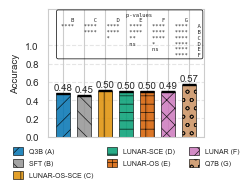

In [132]:
fig, axes = plot_bootstrap_accuracy(
    results, 
    perm_results_df=perm_results,
    model_order=model_order,
    color_order=color_order,
    figsize=(2,2),
    palette="colorblind",
    bar_width=0.7,
    fontsize=7
)

In [133]:
fig.savefig('../figures/fig2_benchmarks.pdf',bbox_inches='tight', dpi=300)